# Model Comparison

This notebook compares Logistic Regression, Decision Tree and Random Forest across all three PCOSense feature sets.

In [1]:
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from pcosense.data import load_clean_data
from pcosense.features import FEATURE_SETS
from pcosense.preprocessing import (
    build_numeric_preprocessor,
    create_train_test_split,
)

data = load_clean_data()
print("Dataset shape:", data.shape)

Dataset shape: (541, 44)


In [2]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_test, predictions, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(
            y_test, probabilities
        ),
    }

In [3]:
def create_models():
    return {
        "logistic_regression": Pipeline([
            (
                "preprocessor",
                build_numeric_preprocessor(scale=True)
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42,
                )
            ),
        ]),

        "decision_tree": Pipeline([
            (
                "preprocessor",
                build_numeric_preprocessor(scale=False)
            ),
            (
                "model",
                DecisionTreeClassifier(
                    max_depth=4,
                    min_samples_leaf=10,
                    class_weight="balanced",
                    random_state=42,
                )
            ),
        ]),

        "random_forest": Pipeline([
            (
                "preprocessor",
                build_numeric_preprocessor(scale=False)
            ),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=6,
                    min_samples_leaf=5,
                    class_weight="balanced",
                    random_state=42,
                    n_jobs=-1,
                )
            ),
        ]),
    }

In [4]:
model_results = []
trained_models = {}

for feature_set, features in FEATURE_SETS.items():
    X_train, X_test, y_train, y_test = (
        create_train_test_split(
            data=data,
            features=features,
            test_size=0.2,
            random_state=42,
        )
    )

    for model_name, model in create_models().items():
        model.fit(X_train, y_train)

        metrics = evaluate_model(
            model,
            X_test,
            y_test
        )

        model_results.append({
            "feature_set": feature_set,
            "model": model_name,
            **metrics,
        })

        trained_models[(feature_set, model_name)] = model

results_df = pd.DataFrame(model_results)

metric_columns = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
]

results_df[metric_columns] = (
    results_df[metric_columns].round(3)
)

display(
    results_df.sort_values(
        "roc_auc",
        ascending=False
    )
)

,feature_set,model,accuracy,precision,recall,f1,roc_auc,pr_auc
6,full_clinical,logistic_regression,0.881,0.795,0.861,0.827,0.946,0.934
8,full_clinical,random_forest,0.899,0.838,0.861,0.849,0.944,0.932
7,full_clinical,decision_tree,0.862,0.800,0.778,0.789,0.922,0.883
5,screening_plus_labs,random_forest,0.872,0.789,0.833,0.811,0.898,0.790
0,screening,logistic_regression,0.835,0.725,0.806,0.763,0.884,0.801
3,screening_plus_labs,logistic_regression,0.798,0.667,0.778,0.718,0.884,0.768
2,screening,random_forest,0.862,0.784,0.806,0.795,0.884,0.802
4,screening_plus_labs,decision_tree,0.826,0.758,0.694,0.725,0.860,0.712
1,screening,decision_tree,0.826,0.758,0.694,0.725,0.812,0.704


## Initial model comparison

Random Forest achieves the highest holdout F1 score for all three feature sets. The full clinical Random Forest performs best overall with an F1 score of 0.849.

However, these results come from one test split. Five-fold stratified cross-validation is required to check whether the performance is stable.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
)

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

In [6]:
cv_results = []

for feature_set, features in FEATURE_SETS.items():
    X = data[features]
    y = data["PCOS (Y/N)"]

    for model_name, model in create_models().items():
        scores = cross_validate(
            model,
            X,
            y,
            cv=cross_validation,
            scoring=scoring,
            n_jobs=1,
        )

        result = {
            "feature_set": feature_set,
            "model": model_name,
        }

        for metric in scoring:
            result[f"{metric}_mean"] = np.mean(
                scores[f"test_{metric}"]
            )
            result[f"{metric}_std"] = np.std(
                scores[f"test_{metric}"]
            )

        cv_results.append(result)

In [7]:
cv_results_df = pd.DataFrame(cv_results)

numeric_columns = cv_results_df.select_dtypes(
    include="number"
).columns

cv_results_df[numeric_columns] = (
    cv_results_df[numeric_columns].round(3)
)

display(
    cv_results_df.sort_values(
        "roc_auc_mean",
        ascending=False
    )
)

,feature_set,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
8,full_clinical,random_forest,0.900,0.023,0.839,0.019,0.859,0.072,0.848,0.041,0.959,0.009,0.934,0.013
6,full_clinical,logistic_regression,0.883,0.027,0.792,0.060,0.882,0.027,0.833,0.034,0.945,0.008,0.918,0.005
7,full_clinical,decision_tree,0.832,0.028,0.703,0.049,0.854,0.053,0.769,0.032,0.912,0.022,0.823,0.042
5,screening_plus_labs,random_forest,0.819,0.022,0.706,0.037,0.769,0.047,0.735,0.032,0.891,0.025,0.807,0.064
2,screening,random_forest,0.828,0.025,0.717,0.040,0.786,0.041,0.749,0.036,0.889,0.028,0.812,0.072
0,screening,logistic_regression,0.823,0.026,0.702,0.048,0.808,0.031,0.750,0.028,0.880,0.029,0.814,0.071
3,screening_plus_labs,logistic_regression,0.810,0.034,0.687,0.056,0.780,0.053,0.729,0.042,0.869,0.035,0.803,0.064
1,screening,decision_tree,0.754,0.016,0.600,0.022,0.746,0.039,0.665,0.026,0.820,0.022,0.684,0.063
4,screening_plus_labs,decision_tree,0.760,0.040,0.613,0.056,0.740,0.078,0.668,0.051,0.814,0.028,0.640,0.039


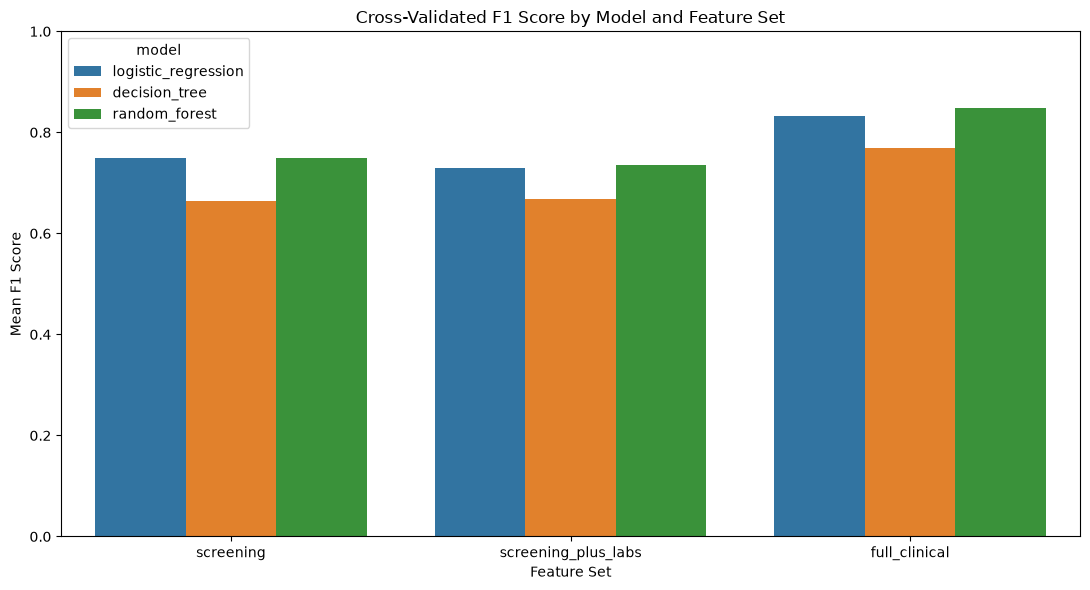

In [8]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=cv_results_df,
    x="feature_set",
    y="f1_mean",
    hue="model",
)

plt.title("Cross-Validated F1 Score by Model and Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("Mean F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Cross-validation findings

- Random Forest performs best on the full clinical feature set, with a mean F1 score of 0.848 and ROC-AUC of 0.959.
- Logistic Regression and Random Forest perform almost equally on screening features.
- Logistic Regression has slightly higher screening recall, while Random Forest has slightly higher accuracy and ROC-AUC.
- Adding laboratory features does not improve performance.
- Decision Tree performs worse than the other models across all feature sets.
- The full clinical advantage is likely influenced by ultrasound follicle features and must not be presented as diagnostic performance.

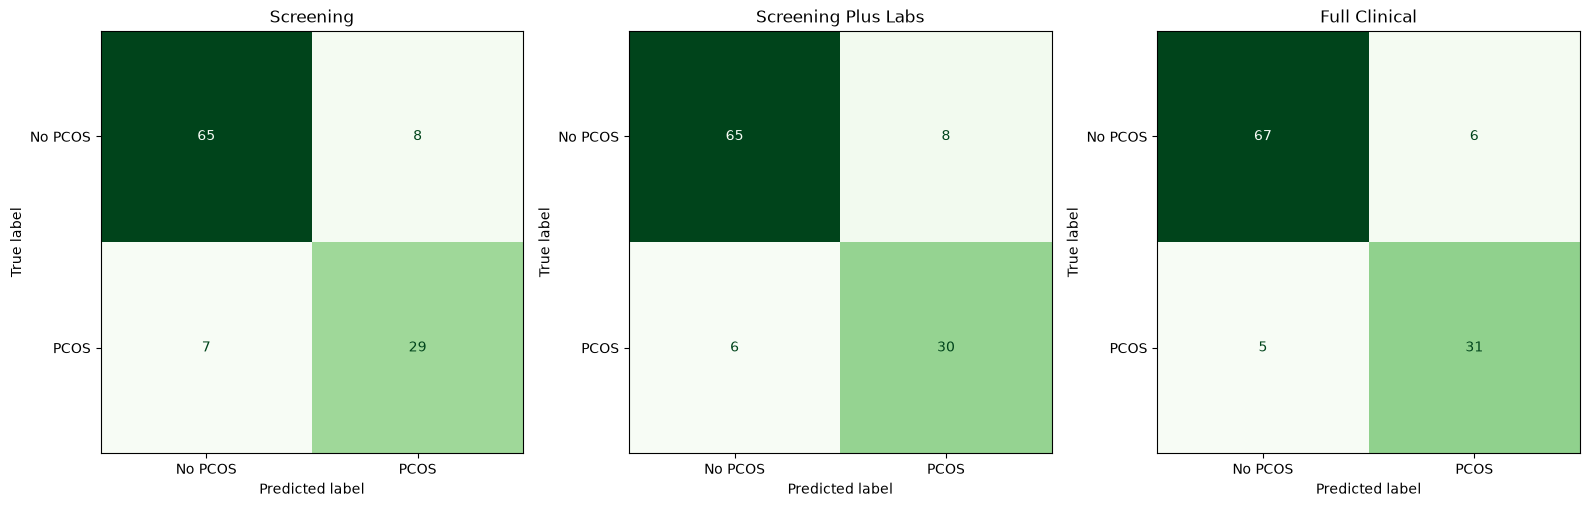

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for axis, feature_set in zip(axes, FEATURE_SETS):
    features = FEATURE_SETS[feature_set]

    X_train, X_test, y_train, y_test = (
        create_train_test_split(
            data=data,
            features=features,
            test_size=0.2,
            random_state=42,
        )
    )

    model = trained_models[
        (feature_set, "random_forest")
    ]

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["No PCOS", "PCOS"],
        cmap="Greens",
        colorbar=False,
        ax=axis,
    )

    axis.set_title(
        feature_set.replace("_", " ").title()
    )

plt.tight_layout()
plt.show()

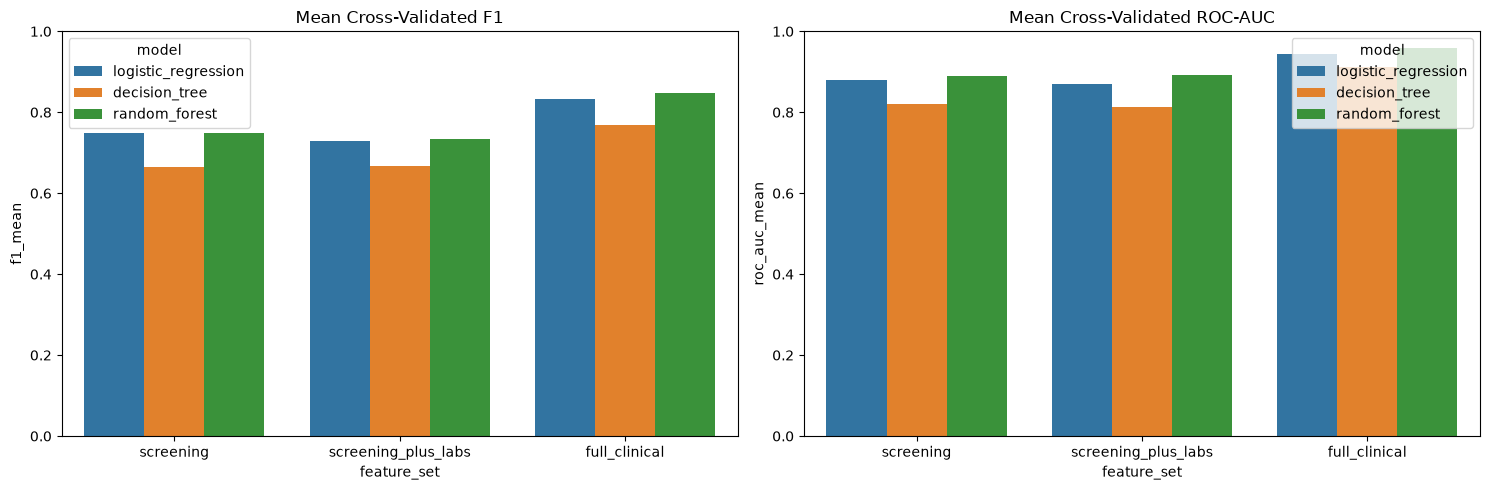

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=cv_results_df,
    x="feature_set",
    y="f1_mean",
    hue="model",
    ax=axes[0],
)

axes[0].set_title("Mean Cross-Validated F1")
axes[0].set_ylim(0, 1)

sns.barplot(
    data=cv_results_df,
    x="feature_set",
    y="roc_auc_mean",
    hue="model",
    ax=axes[1],
)

axes[1].set_title("Mean Cross-Validated ROC-AUC")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_PATH = (
    PROJECT_ROOT
    / "reports"
    / "model_comparison.csv"
)

cv_results_df.sort_values(
    "roc_auc_mean",
    ascending=False
).to_csv(RESULTS_PATH, index=False)

print("Saved to:", RESULTS_PATH)

Saved to: c:\Users\Shreya Rathore\OneDrive\Desktop\PCOSense\reports\model_comparison.csv


## Model-comparison conclusion

Random Forest is currently the strongest full-clinical model. For the screening application, Logistic Regression and Random Forest remain both viable.

The screening model is more relevant to the eventual user interface because it does not require laboratory or ultrasound inputs. Final selection will follow hyperparameter tuning, threshold evaluation and explainability analysis.